<hr>
<h1><center>| Projet 4: Construisez un modèle de scoring |</center></h1>

<hr>
<h1><center>| Modélisation |</center></h1>

<br>
<br>

>__Réalisé par : Said Arrazouaki__

In [1]:
random_state = 123

In [2]:
import warnings

warnings.filterwarnings("ignore")

In [3]:
import pandas as pd

data = pd.read_pickle("./data_cleaned/data.pkl")

data.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,ANNUITY_CREDIT_RATIO,bureau_active_loans_count_x,bureau_avg_days_overdue_x,bureau_active_loans_count_y,bureau_avg_days_overdue_y,installment_late_payment_percentage,credit_card_avg_usage,credit_card_avg_days_past_due,credit_card_avg_usage_missing,credit_card_avg_days_past_due_missing
0,100002.0,1,Cash loans,M,N,Y,0.0,202500.0,406597.5,24700.5,...,0.060749,2.0,0.0,2.0,0.0,0.000000,0.0,0.0,1,1
1,100003.0,0,Cash loans,F,N,N,0.0,270000.0,1293502.5,35698.5,...,0.027598,1.0,0.0,1.0,0.0,0.000000,0.0,0.0,1,1
2,100004.0,0,Revolving loans,M,Y,Y,0.0,67500.0,135000.0,6750.0,...,0.050000,2.0,0.0,2.0,0.0,0.000000,0.0,0.0,1,1
3,100006.0,0,Cash loans,F,N,Y,0.0,135000.0,312682.5,29686.5,...,0.094941,2.0,0.0,2.0,0.0,0.000000,0.0,0.0,0,0
4,100007.0,0,Cash loans,M,N,Y,0.0,121500.0,513000.0,21865.5,...,0.042623,2.0,0.0,2.0,0.0,0.242424,0.0,0.0,1,1


In [4]:
data.shape

(306856, 93)

In [5]:
data.TARGET.value_counts()

TARGET
0    282098
1     24758
Name: count, dtype: int64

In [6]:
data.dtypes.value_counts()

object     48
float64    45
Name: count, dtype: int64

In [7]:
data_cat = data.select_dtypes(include=["object"])

In [8]:
data_cat.head()

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,credit_card_avg_usage_missing,credit_card_avg_days_past_due_missing
0,1,Cash loans,M,N,Y,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,...,0,0,0,0,0,0,0,0,1,1
1,0,Cash loans,F,N,N,Family,State servant,Higher education,Married,House / apartment,...,0,0,0,0,0,0,0,0,1,1
2,0,Revolving loans,M,Y,Y,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,...,0,0,0,0,0,0,0,0,1,1
3,0,Cash loans,F,N,Y,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,...,0,0,0,0,0,0,0,0,0,0
4,0,Cash loans,M,N,Y,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,...,0,0,0,0,0,0,0,0,1,1


In [9]:
cat_col = data_cat.columns

In [10]:
for col in cat_col:
    print(f"For {col} there is : {data[col].nunique()} unique values")

For TARGET there is : 2 unique values
For NAME_CONTRACT_TYPE there is : 2 unique values
For CODE_GENDER there is : 2 unique values
For FLAG_OWN_CAR there is : 2 unique values
For FLAG_OWN_REALTY there is : 2 unique values
For NAME_TYPE_SUITE there is : 7 unique values
For NAME_INCOME_TYPE there is : 8 unique values
For NAME_EDUCATION_TYPE there is : 5 unique values
For NAME_FAMILY_STATUS there is : 6 unique values
For NAME_HOUSING_TYPE there is : 6 unique values
For FLAG_MOBIL there is : 2 unique values
For FLAG_EMP_PHONE there is : 2 unique values
For FLAG_WORK_PHONE there is : 2 unique values
For FLAG_CONT_MOBILE there is : 2 unique values
For FLAG_PHONE there is : 2 unique values
For FLAG_EMAIL there is : 2 unique values
For OCCUPATION_TYPE there is : 18 unique values
For WEEKDAY_APPR_PROCESS_START there is : 7 unique values
For REG_REGION_NOT_LIVE_REGION there is : 2 unique values
For REG_REGION_NOT_WORK_REGION there is : 2 unique values
For LIVE_REGION_NOT_WORK_REGION there is : 2

In [11]:
data_cat['ORGANIZATION_TYPE'].value_counts()['XNA']/data_cat.shape[0]*100

np.float64(18.00942461610658)

In [12]:
data.isna().sum().sum()

np.int64(0)

## Evaluation du performance

#### Critères d'Évaluation des Modèles

- Performance, mesurée par : métrique personalisé , ROC AUC
- Vitesse d'exécution
- Interprétabilité


#### Métriques de Performance

**-Matrice de Confusion**

|               | Prédiction : 0 | Prédiction : 1 |
|---------------|-----------------|-----------------|
| **Réel : 0**  | True Negative (TN) | False Positive (FP) |
| **Réel : 1**  | False Negative (FN) | True Positive (TP) |


**-Accuracy** : Représente le pourcentage de bonnes prédictions faites par le modèle :
$$accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

**-Recall** : Indique le pourcentage de positifs correctement prédits :
$$recall = \frac{TP}{TP + FN}$$
Un recall élevé maximise le nombre de vrais positifs, mais n'indique pas la qualité des prédictions sur les négatifs.

**-Precision** : Mesure le nombre de prédictions positives correctes :
$$precision = \frac{TP}{TP + FP}$$
Une précision élevée signifie que la majorité des prédictions positives sont correctes, réduisant les faux positifs.

#### Courbe ROC et AUC

La courbe ROC montre le taux de vrais positifs (recall) en fonction du taux de faux positifs :
- **TPR** (taux de vrais positifs) : $$TPR = \frac{TP}{TP + FN}$$
- **FPR** (taux de faux positifs) : $$FPR = \frac{FP}{FP + TN}$$

L'AUC est l'aire sous la courbe ROC, mesurant la capacité du modèle à distinguer les classes :
- AUC = 1 : modèle parfait
- AUC = 0 : modèle totalement incorrect
L’AUC est indépendante des seuils de classification et de l’échelle.

**Note** : Dans notre cas, une étiquette de sortie "1" indique un défaut de paiement, et "0" une absence de défaut. Nous cherchons donc à privilégier des modèles qui minimisent les faux négatifs.

In [13]:
from sklearn.metrics import confusion_matrix


# Fonction personnalisée
def score_personnalise(y_true, y_pred):
    """
    Fonction calculant une métrique personnalisée pour évaluer les erreurs du modèle.

    Args:
    y_true : Les vraies étiquettes de classe.
    y_pred : Les prédictions du modèle.

    Returns:
    int : La valeur de la métrique personnalisée (10 * FN + FP).
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return -(10 * fn + fp)


In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt


# Rapport de performance
def generate_model_report(model, X_test, y_test):
    """
    Fonction générant un rapport de performance pour un modèle de classification.

    Args:
    modele : Le modèle déjà entraîné.
    X_test : Ensemble de test des caractéristiques.
    y_test : Étiquettes de l'ensemble de test.

    Affiche les métriques dans la console.
    Génère également un graphique de matrice de confusion.
    """
    y_pred = model.predict(X_test)
    print("-----------------------------------------")
    print(f"Accuracy      = {round(accuracy_score(y_test, y_pred), 3)}")
    print(f"Precision     = {round(precision_score(y_test, y_pred), 3)}")
    print(f"Recall        = {round(recall_score(y_test, y_pred), 3)}")
    print(f"f1_score      = {round(f1_score(y_test, y_pred), 3)}")
    print(f"Custom metric = {- score_personnalise(y_test, y_pred)}")
    print("-----------------------------------------")

    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
    _ = plt.title("Matrice de confusion", fontsize=20)


In [15]:
from sklearn.metrics import roc_auc_score, roc_curve


#
def generate_roc_curve(model, X_test, y_test):
    """
    Fonction générant et affichant la courbe ROC pour un modèle de classification.

    Args:
    model : Le modèle de classification entraîné.
    X : Les caractéristiques de l'ensemble de données.
    y : Les vraies étiquettes de classe.

    Affiche la courbe ROC et les scores AUC pour le modèle et une baseline.
    """

    y_pred_proba = model.predict_proba(X_test)[:, 1]
    ns_probs = [0 for i in range(len(y_test))]

    # Calcul des scores AUC
    ns_auc = roc_auc_score(y_test, ns_probs)
    auc = roc_auc_score(y_test, y_pred_proba)

    print(f"{type(model).__name__}      : ROC AUC=%.3f" % (auc))

    # Calcul des courbes ROC
    ns_fpr, ns_tpr, _ = roc_curve(y_test, ns_probs)
    lr_fpr, lr_tpr, _ = roc_curve(y_test, y_pred_proba)

    # Tracer la courbe ROC
    if type(model).__name__ != "DummyClassifier":
        print("DummyClassifier      : ROC AUC=%.3f" % (ns_auc))
        plt.plot(
            ns_fpr,
            ns_tpr,
            linestyle="--",
            label=f"DummyClassifier (AUC = {ns_auc})",
            lw=1.5,
        )
    plt.plot(
        lr_fpr,
        lr_tpr,
        label=f"{type(model).__name__} (AUC = {auc:.3f})",
        marker="+",
        lw=2,
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(bbox_to_anchor=(1.05, 0.95), loc="upper left")
    plt.title("Receiver Operating Characteristic curve", fontsize=20)
    plt.show()


## Modélisation

In [16]:
X = data.drop(columns=["TARGET", "SK_ID_CURR"])
y = data["TARGET"].astype(int)

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=random_state
)

### Modèle de référence: DummyClassifier

Nous utiliserons comme modèle de référence le `DummyClassifier` de `scikit-learn` qui fait des prédictions aléatoires avec le paramètre `strategy="constant` :

In [18]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="constant", constant=0)

dummy.fit(X_train, y_train)


,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'constant'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",0


In [19]:
type(dummy).__name__


'DummyClassifier'

-----------------------------------------
Accuracy      = 0.921
Precision     = 0.0
Recall        = 0.0
f1_score      = 0.0
Custom metric = 60340
-----------------------------------------


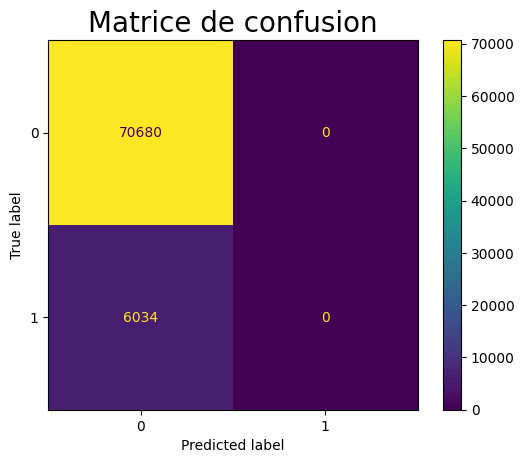

In [20]:
generate_model_report(dummy, X_test, y_test)

DummyClassifier      : ROC AUC=0.500


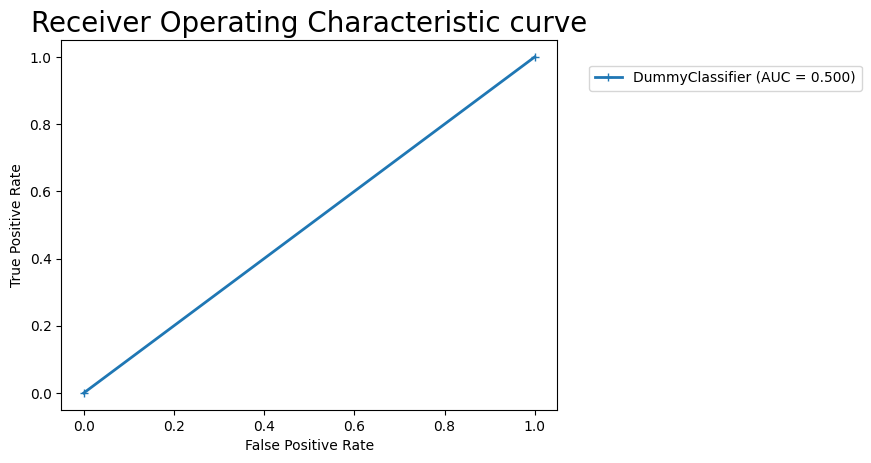

In [21]:
generate_roc_curve(dummy, X_test, y_test)

### Régression logistique

In [22]:
categorical_features = X.select_dtypes(include="object").columns.to_list()
numerical_features = X.select_dtypes(exclude="object").columns.to_list()

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_preprocessor = OneHotEncoder(handle_unknown="ignore", drop="first")

numerical_preprocessor = StandardScaler()

preprocessor_linear = ColumnTransformer(
    [
        ("cat_preprocessor", categorical_preprocessor, categorical_features),
        ("num_preprocessor", numerical_preprocessor, numerical_features),
    ]
)

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

linear_model = Pipeline(
    [
        ("preprocessor", preprocessor_linear),
        (
            "classifier",
            LogisticRegression(C=1, class_weight="balanced"),
        ),
    ]
)


In [25]:
linear_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat_preprocessor', ...), ('num_preprocessor', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output o

-----------------------------------------
Accuracy      = 0.696
Precision     = 0.161
Recall        = 0.679
f1_score      = 0.26
Custom metric = 40737
-----------------------------------------


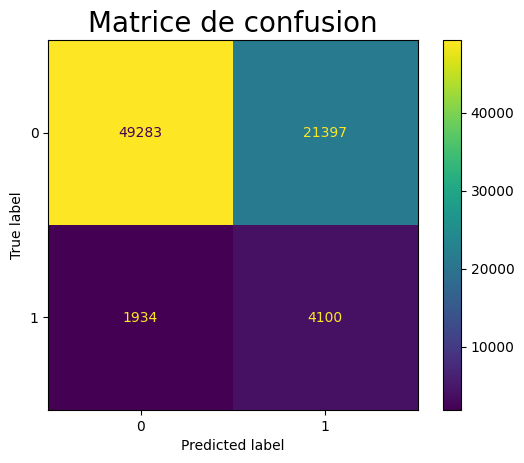

In [26]:
generate_model_report(linear_model, X_test, y_test)

Pipeline      : ROC AUC=0.754
DummyClassifier      : ROC AUC=0.500


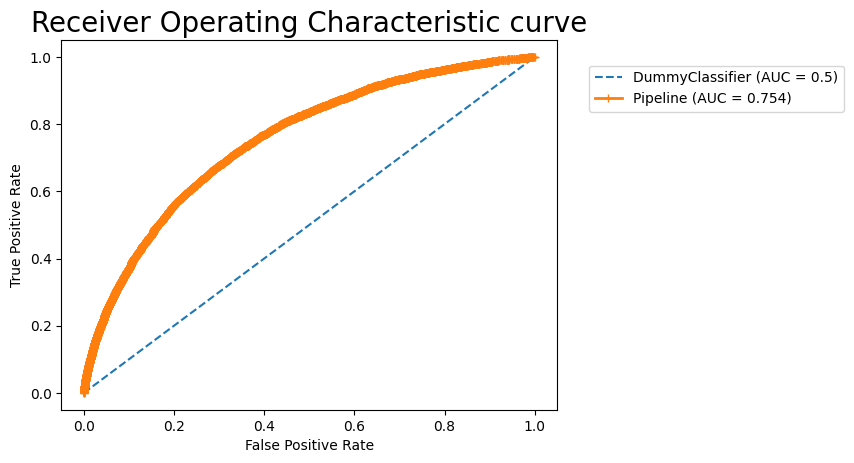

In [27]:
generate_roc_curve(linear_model, X_test, y_test)

### Les arbres de decisions

In [28]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OrdinalEncoder

categorical_preprocessor = OrdinalEncoder(
    handle_unknown="use_encoded_value", unknown_value=-1
)

preprocessor = ColumnTransformer(
    [("cat_preprocessor", categorical_preprocessor, categorical_features)],
    remainder="passthrough",
)

tree_model = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(class_weight="balanced", max_depth=5),
        ),
    ]
)

In [29]:
tree_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat_preprocessor', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

-----------------------------------------
Accuracy      = 0.691
Precision     = 0.146
Recall        = 0.606
f1_score      = 0.236
Custom metric = 45089
-----------------------------------------


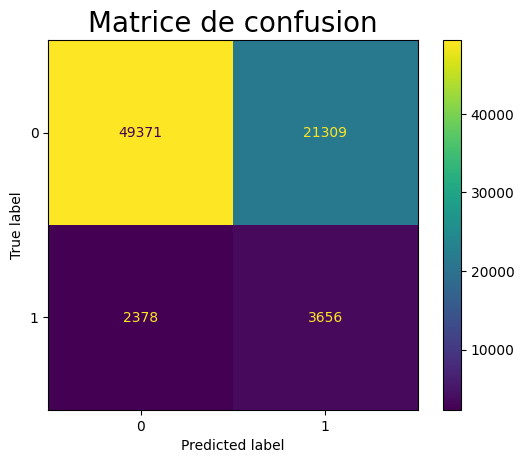

In [30]:
generate_model_report(tree_model, X_test, y_test)

Pipeline      : ROC AUC=0.707
DummyClassifier      : ROC AUC=0.500


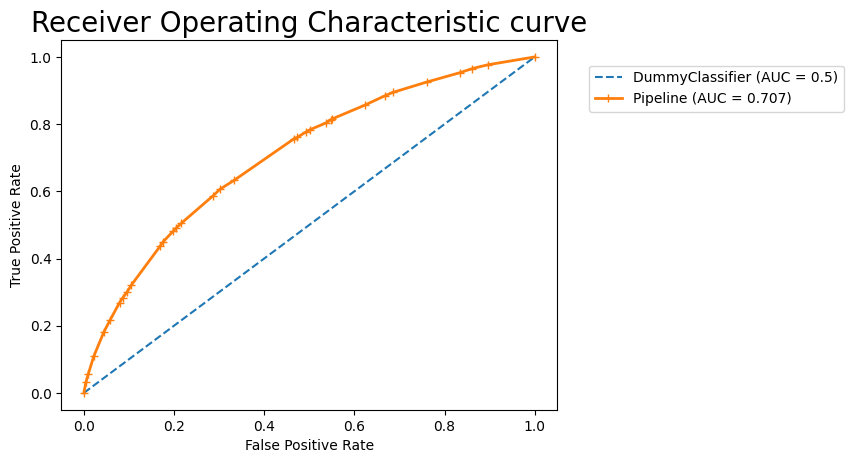

In [31]:
generate_roc_curve(tree_model, X_test, y_test)

### Random forest

In [32]:
from sklearn.ensemble import RandomForestClassifier


random_forest_model = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                class_weight="balanced",
                max_depth=5,
                n_estimators=500,
                random_state=random_state,
            ),
        ),
    ]
)

In [34]:
random_forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat_preprocessor', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

-----------------------------------------
Accuracy      = 0.68
Precision     = 0.152
Recall        = 0.669
f1_score      = 0.247
Custom metric = 42526
-----------------------------------------


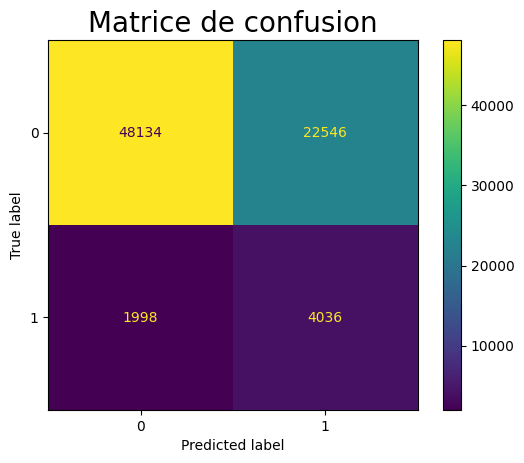

In [35]:
generate_model_report(random_forest_model, X_test, y_test)

Pipeline      : ROC AUC=0.734
DummyClassifier      : ROC AUC=0.500


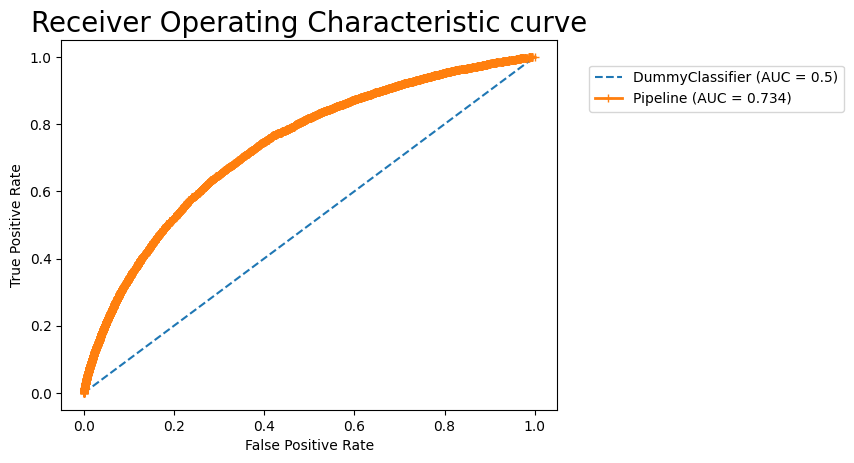

In [36]:
generate_roc_curve(random_forest_model, X_test, y_test)

### Histogram gradiend boosting classifier

In [40]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgbc_model = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "classifier",
            HistGradientBoostingClassifier(
                random_state=42, max_leaf_nodes=4, class_weight="balanced"
            ),
        ),
    ]
)
hgbc_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat_preprocessor', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

-----------------------------------------
Accuracy      = 0.698
Precision     = 0.162
Recall        = 0.679
f1_score      = 0.261
Custom metric = 40629
-----------------------------------------


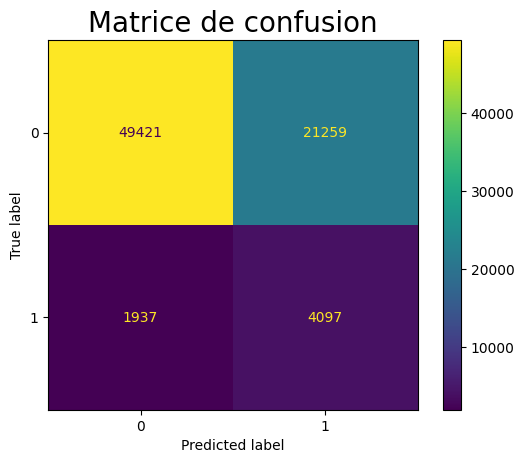

In [41]:
generate_model_report(hgbc_model, X_test, y_test)

Pipeline      : ROC AUC=0.753
DummyClassifier      : ROC AUC=0.500


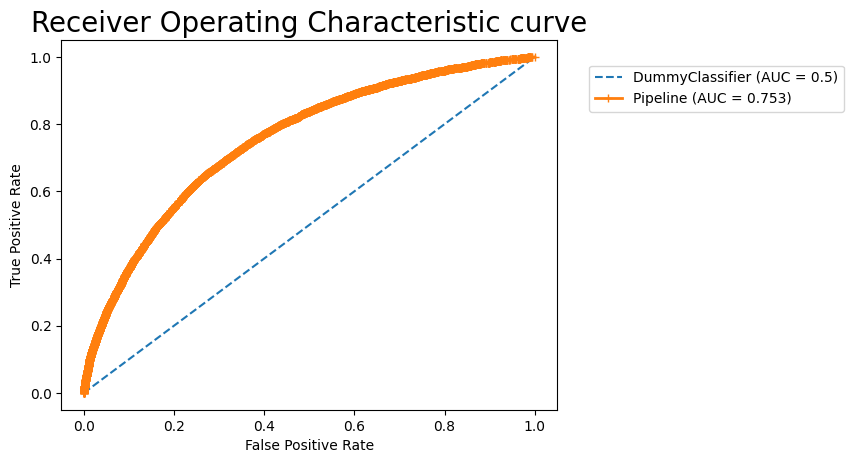

In [42]:
generate_roc_curve(hgbc_model, X_test, y_test)

### XGboost

In [46]:
from xgboost import XGBClassifier

# Compute scale_pos_weight as the ratio of the majority class to the minority class
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb_model = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                random_state=42,
                max_depth=2,
                n_estimators=500,
                scale_pos_weight=scale_pos_weight,
            ),
        ),
    ]
)
xgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat_preprocessor', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

-----------------------------------------
Accuracy      = 0.716
Precision     = 0.172
Recall        = 0.683
f1_score      = 0.274
Custom metric = 39020
-----------------------------------------


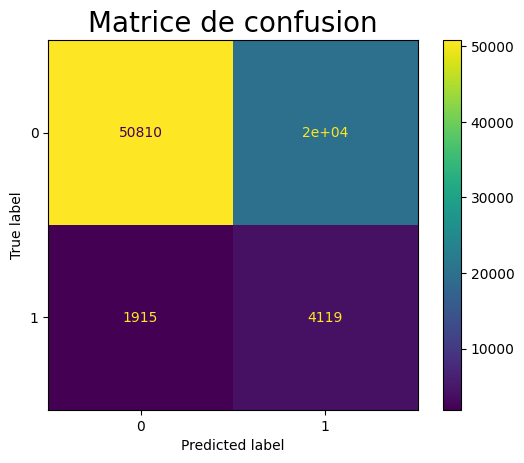

In [47]:
generate_model_report(xgb_model, X_test, y_test)

Pipeline      : ROC AUC=0.766
DummyClassifier      : ROC AUC=0.500


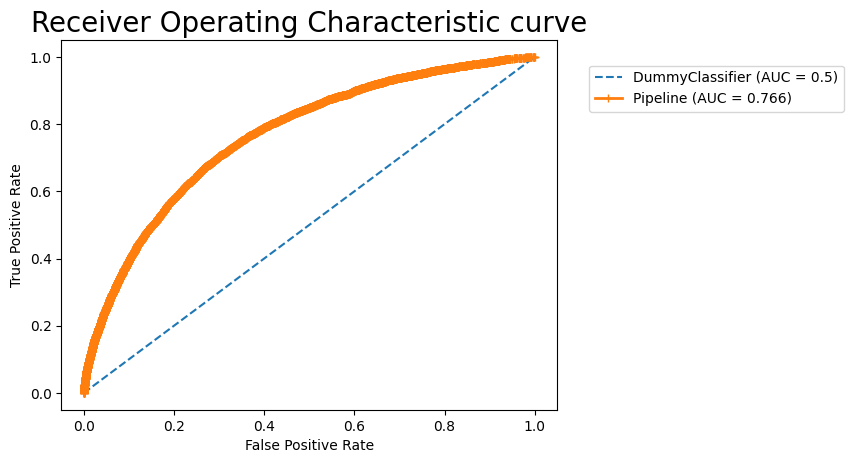

In [48]:
generate_roc_curve(xgb_model, X_test, y_test)

### LightGBM

In [49]:
from lightgbm import LGBMClassifier

# Compute scale_pos_weight as the ratio of the majority class to the minority class
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

lgbm_model = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "classifier",
            LGBMClassifier(
                random_state=random_state,
                max_depth=10,
                n_estimators=1000,
                learning_rate=0.02,
                scale_pos_weight=scale_pos_weight,
            ),
        ),
    ]
)
lgbm_model.fit(X_train, y_train)


[LightGBM] [Info] Number of positive: 18724, number of negative: 211418
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032543 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6292
[LightGBM] [Info] Number of data points in the train set: 230142, number of used features: 87
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.081358 -> initscore=-2.424031
[LightGBM] [Info] Start training from score -2.424031


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat_preprocessor', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

-----------------------------------------
Accuracy      = 0.723
Precision     = 0.173
Recall        = 0.67
f1_score      = 0.275
Custom metric = 39206
-----------------------------------------


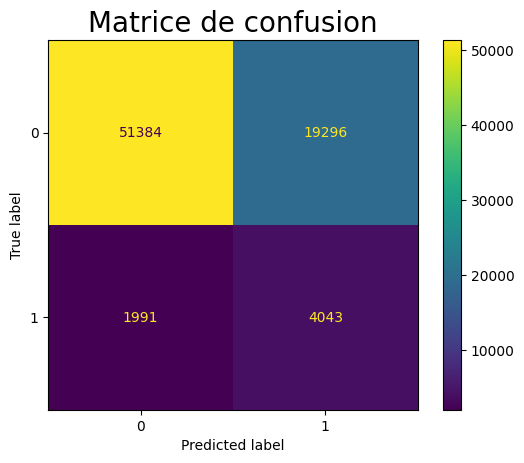

In [50]:
generate_model_report(lgbm_model, X_test, y_test)

Pipeline      : ROC AUC=0.766
DummyClassifier      : ROC AUC=0.500


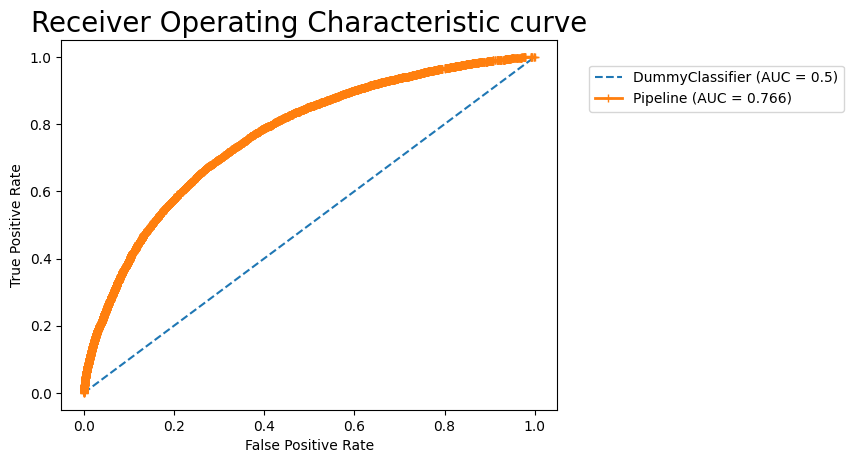

In [51]:
generate_roc_curve(lgbm_model, X_test, y_test)